<a href="https://colab.research.google.com/github/forgetallyourworries/Pedjuang-Kompis-IDSC/blob/main/projek_jst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prettytable
# !pip show numpy scikit-learn
from keras.losses import binary_crossentropy, categorical_crossentropy

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from prettytable import PrettyTable
from prettytable import ALL
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve

K = tf.keras.backend


In [ ]:
# Ganti path sesuai lokasi file Anda
df = pd.read_csv('/content/drive/MyDrive/projek pkc/archive/hypertension_data.csv')

# Tampilkan informasi awal
print(df.info())
print(df.head())
print("Distribusi target:")
print(df['target'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26083 entries, 0 to 26082
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       26083 non-null  float64
 1   sex       26058 non-null  float64
 2   cp        26083 non-null  int64  
 3   trestbps  26083 non-null  int64  
 4   chol      26083 non-null  int64  
 5   fbs       26083 non-null  int64  
 6   restecg   26083 non-null  int64  
 7   thalach   26083 non-null  int64  
 8   exang     26083 non-null  int64  
 9   oldpeak   26083 non-null  float64
 10  slope     26083 non-null  int64  
 11  ca        26083 non-null  int64  
 12  thal      26083 non-null  int64  
 13  target    26083 non-null  int64  
dtypes: float64(3), int64(11)
memory usage: 2.8 MB
None
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0  57.0  1.0   3       145   233    1        0      150      0      2.3   
1  64.0  0.0   2       130   250    0        1      187      

In [ ]:
# Ganti tanda tanya dengan NaN jika ada
df.replace('?', np.nan, inplace=True)

# Konversi semua kolom ke numerik jika memungkinkan
df = df.apply(pd.to_numeric, errors='coerce')

# Drop baris dengan nilai NaN
df.dropna(inplace=True)

# Seleksi fitur dan target
X = df.drop('target', axis=1).values
y = df['target'].values  # Pastikan y berbentuk kolom

# Split data menjadi data latih dan data uji
# === STEP 1: Split data → Train (70%) + Temp (30%) ===
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# === STEP 2: Split Temp → Validation (15%) + Test (15%) ===
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Handle Class Imbalance with SMOTE NC
categorical_features = [i for i, col in enumerate(df.columns)
                        if col in ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']]
# SMOTENC
smote_nc = SMOTENC(
    categorical_features=categorical_features,
    k_neighbors=5,
    sampling_strategy='minority',  # Fokus pada kelas minoritas
    random_state=42
)

# Resampling
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

# Update y_train
y_train = y_train_resampled

# Post-processing untuk fitur kategorikal
for i in categorical_features:
    # Pertama, pastikan dalam bentuk integer
    X_train_resampled[:, i] = np.round(X_train_resampled[:, i]).astype(int)

    # Pastikan nilai dalam range valid
    if i == df.columns.get_loc('sex'):
        X_train_resampled[:, i] = np.clip(X_train_resampled[:, i], 0, 1)
    elif i == df.columns.get_loc('ca'):
        X_train_resampled[:, i] = np.clip(X_train_resampled[:, i], 0, 4)

# Standarisasi fitur
scaler = StandardScaler()
# Fit scaler on resampled training data
X_train_scaled = scaler.fit_transform(X_train_resampled)  # Use resampled data here
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Update m (number of training samples)
m = X_train_scaled.shape[0]  # This should now reflect the resampled count

In [ ]:
# Fungsi aktivasi dan turunannya
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Fungsi cetak tabel bobot
def print_weight_table(weights, prefix="w"):
    """Cetak bobot dalam format horizontal seperti laporan"""
    n_rows, n_cols = weights.shape
    for i in range(min(n_rows, 32)):  # Tampilkan maksimal 3 baris
        labels = [f"{prefix}{i+1}{j+1}" for j in range(n_cols)]
        values = [f"{weights[i, j]:<6.2f}" for j in range(n_cols)]
        print(" | ".join(labels))
        print(" | ".join(values))
        print()

# Fungsi cetak tabel bias
def print_bias_table(bias, prefix="b"):
    labels = [f"{prefix}{j+1}" for j in range(bias.shape[1])]
    values = [f"{bias[0, j]:<6.2f}" for j in range(bias.shape[1])]
    print(" | ".join(labels))
    print(" | ".join(values))
    print()

# Inisialisasi parameter
input_size = X_train_scaled.shape[1]  # Jumlah fitur (13)
hidden_size1 = 256              # Ukuran hidden layer 1
hidden_size2 = 128              # Ukuran hidden layer 2
hidden_size3 = 64
output_size = 1
learning_rate = 0.005
min_learning_rate = 1e-5
grad_clip_value = 1.0
epochs = 4000
best_val_f1 = 0
patience = 20
patience_counter = 0
dropout_rate = 0.3

#He initialization secara random
W1 = np.random.randn(input_size, hidden_size1) * np.sqrt(2. / input_size)
b1 = np.zeros((1, hidden_size1))

W2 = np.random.randn(hidden_size1, hidden_size2) * np.sqrt(2. / hidden_size1)
b2 = np.zeros((1, hidden_size2))

W3 = np.random.randn(hidden_size2, hidden_size3) * np.sqrt(2. / hidden_size2)
b3 = np.zeros((1, hidden_size3))

W4 = np.random.randn(hidden_size3, output_size) * np.sqrt(2. / hidden_size3)  # Layer output baru
b4 = np.zeros((1, output_size))

# Untuk menyimpan loss dan akurasi
loss_history = []
accuracy_history = []
val_loss_history = []
f1_history = []
val_f1_history = []
m = X_train_scaled.shape[0]

# Cetak bobot dan bias dalam format tabulasi
print(f"{'Layer':<8} | {'Weight Shape':<15} | {'Bias Shape':<15}")
print("-" * 45)
print(f"{'W1':<8} | {str(W1.shape):<15} | {str(b1.shape):<15}")
print(f"{'W2':<8} | {str(W2.shape):<15} | {str(b2.shape):<15}")
print(f"{'W3':<8} | {str(W3.shape):<15} | {str(b3.shape):<15}")
print("\nContoh isi bobot dan bias:")

# Cetak bobot dan bias seperti laporan
print("2. Bobot dan Bias")
print("a. Hidden Layer 1 (W1 dan b1)")
print_weight_table(W1, prefix="w1")
print_bias_table(b1, prefix="b1")

print("a. Hidden Layer 2 (W2 dan b2)")
print_weight_table(W2, prefix="w2")
print_bias_table(b2, prefix="b2")

print("b. Output Layer (W3 dan b3)")
print_weight_table(W3.T, prefix="w3")  # Transpose karena hanya 1 output neuron
print_bias_table(b3, prefix="b3")

Layer    | Weight Shape    | Bias Shape     
---------------------------------------------
W1       | (13, 256)       | (1, 256)       
W2       | (256, 128)      | (1, 128)       
W3       | (128, 64)       | (1, 64)        

Contoh isi bobot dan bias:
2. Bobot dan Bias
a. Hidden Layer 1 (W1 dan b1)
w111 | w112 | w113 | w114 | w115 | w116 | w117 | w118 | w119 | w1110 | w1111 | w1112 | w1113 | w1114 | w1115 | w1116 | w1117 | w1118 | w1119 | w1120 | w1121 | w1122 | w1123 | w1124 | w1125 | w1126 | w1127 | w1128 | w1129 | w1130 | w1131 | w1132 | w1133 | w1134 | w1135 | w1136 | w1137 | w1138 | w1139 | w1140 | w1141 | w1142 | w1143 | w1144 | w1145 | w1146 | w1147 | w1148 | w1149 | w1150 | w1151 | w1152 | w1153 | w1154 | w1155 | w1156 | w1157 | w1158 | w1159 | w1160 | w1161 | w1162 | w1163 | w1164 | w1165 | w1166 | w1167 | w1168 | w1169 | w1170 | w1171 | w1172 | w1173 | w1174 | w1175 | w1176 | w1177 | w1178 | w1179 | w1180 | w1181 | w1182 | w1183 | w1184 | w1185 | w1186 | w1187 | w1188 | w11

In [ ]:
for epoch in range(epochs):
    # Forward propagation (dengan 3 hidden layer + 1 output layer)
    z1 = np.dot(X_train_scaled, W1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)
    z3 = np.dot(a2, W3) + b3  # Tambahan forward pass untuk layer ketiga
    a3 = relu(z3)             # Aktivasi relu layer ketiga
    z4 = np.dot(a3, W4) + b4  # Output layer
    a4 = sigmoid(z4)          # Aktivasi sigmoid output layer

    # Hitung loss dan akurasi pelatihan
    y_train_reshaped = y_train.reshape(-1, 1)
    # Gunakan a4 (output layer) untuk menghitung loss dan akurasi
    loss = -np.mean(y_train_reshaped * np.log(a4 + 1e-8) + (1 - y_train_reshaped) * np.log(1 - a4 + 1e-8))
    loss_history.append(loss)

    # Gunakan a4 (output layer) untuk prediksi kelas
    y_train_pred_class = (a4 > 0.5).astype(int)
    accuracy = accuracy_score(y_train, y_train_pred_class.flatten())
    accuracy_history.append(accuracy)

    # Hitung F1-score pelatihan
    train_f1 = f1_score(y_train, y_train_pred_class.flatten(), average='macro')
    f1_history.append(train_f1)

    # Backward propagation
    # Delta untuk output layer (a4)
    dz4 = a4 - y_train_reshaped
    dW4 = np.clip(np.dot(a3.T, dz4) / m, -grad_clip_value, grad_clip_value)
    db4 = np.clip(np.sum(dz4, axis=0, keepdims=True) / m, -grad_clip_value, grad_clip_value)

    # Delta untuk hidden layer 3 (a3)
    da3 = np.dot(dz4, W4.T)
    dz3 = da3 * relu_derivative(z3) # Gunakan derivative relu untuk layer 3
    dW3 = np.dot(a2.T, dz3) / m
    db3 = np.sum(dz3, axis=0, keepdims=True) / m

    # Delta untuk hidden layer 2 (a2)
    da2 = np.dot(dz3, W3.T) # Propagate error dari dz3 ke a2
    dz2 = da2 * relu_derivative(z2)
    dW2 = np.dot(a1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    # Delta untuk hidden layer 1 (a1)
    da1 = np.dot(dz2, W2.T)
    dz1 = da1 * relu_derivative(z1)
    dW1 = np.dot(X_train_scaled.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m


    # Update weights dan biases
    W4 -= learning_rate * dW4
    b4 -= learning_rate * db4
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


    # Hitung metrik validasi setiap epoch
    z1_val = np.dot(X_val_scaled, W1) + b1
    a1_val = relu(z1_val)
    z2_val = np.dot(a1_val, W2) + b2
    a2_val = relu(z2_val)
    z3_val = np.dot(a2_val, W3) + b3  # Layer baru
    a3_val = relu(z3_val)             # Aktivasi layer baru
    z4_val = np.dot(a3_val, W4) + b4  # Output layer
    a4_val = sigmoid(z4_val)          # Output akhir

    # Gunakan a4_val (output layer validasi) untuk menghitung loss dan F1
    val_loss = -np.mean(y_val.reshape(-1, 1) * np.log(a4_val + 1e-8) + (1 - y_val.reshape(-1, 1)) * np.log(1 - a4_val + 1e-8))
    val_loss_history.append(val_loss)
    val_preds = (a4_val >= 0.5).astype(int)  # Gunakan a4_val bukan a3_val
    val_f1 = f1_score(y_val, val_preds, average='macro')
    val_f1_history.append(val_f1)

    # Adaptive learning rate
    if epoch > 0 and epoch % 100 == 0:
        # Gunakan val_loss_history[-1] dan val_loss_history[-2] setelah penyesuaian
        if len(val_loss_history) >= 2 and val_loss_history[-1] > val_loss_history[-2]:
            learning_rate *= 0.7  # Turunkan lebih agresif jika loss naik
        else:
            learning_rate *= 0.95  # Turunkan perlahan

        learning_rate = max(learning_rate, min_learning_rate)

    # if epoch % 500 == 0:
    #   learning_rate *= 0.9


    # Cetak progress setiap 100 epoch
    if (epoch + 1) % 100 == 0:
        # Gunakan a4_val untuk precision_recall_curve
        precisions, recalls, thresholds = precision_recall_curve(y_val, a4_val.flatten())
        # Temukan threshold yang memberikan recall >= 0.7, atau gunakan threshold default 0.5 jika tidak ada yang memenuhi
        # Ini adalah pendekatan yang sedikit berbeda dari sebelumnya, memastikan ada threshold yang dipilih
        best_thresh_recall_70 = 0.5 # Default threshold
        for i in range(len(thresholds)):
            if recalls[i] >= 0.7:
                best_thresh_recall_70 = thresholds[i]
                break # Ambil threshold pertama yang memenuhi

        # Hitung F1-score dengan best_thresh_recall_70 untuk informasi cetak
        val_preds_thresh = (a4_val >= best_thresh_recall_70).astype(int)
        f1_at_best_thresh = f1_score(y_val, val_preds_thresh, average='macro')

        print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.4f}, Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")
        print(f"  Threshold (Recall >= 0.7): {best_thresh_recall_70:.4f}, F1 at this threshold: {f1_at_best_thresh:.4f}")

    # Early stopping logic - uncomment jika ingin digunakan
    # if val_f1 > best_val_f1:
    #     best_val_f1 = val_f1
    #     patience_counter = 0
    #     # Save best weights - perlu implementasi save weights jika early stopping diaktifkan
    # else:
    #     patience_counter += 1
    #     if patience_counter >= patience:
    #         print(f"Early stopping at epoch {epoch+1}")
    #         break

print("Loop selesai")

# Calculate validation loss and F1 *after* the training loop using the final weights
# ----- Forward (Validation) -----
z1_val = np.dot(X_val_scaled, W1) + b1
a1_val = relu(z1_val)
z2_val = np.dot(a1_val, W2) + b2
a2_val = relu(z2_val)
z3_val = np.dot(a2_val, W3) + b3
a3_val = relu(z3_val)
z4_val = np.dot(a3_val, W4) + b4  # Output layer
a4_val = sigmoid(z4_val)          # Output akhir

# Gunakan a4_val untuk final validation loss dan F1
y_val_reshaped = y_val.reshape(-1, 1)
final_val_loss = -np.mean(y_val_reshaped * np.log(a4_val + 1e-8) + (1 - y_val_reshaped) * np.log(1 - a4_val + 1e-8))
final_val_preds = (a4_val >= 0.5).astype(int)
final_val_f1 = f1_score(y_val, final_val_preds, average='macro')

print(f"\nFinal Validation Loss (default threshold 0.5): {final_val_loss:.4f}")
print(f"Final Validation F1 Score (default threshold 0.5): {final_val_f1:.4f}")


# Tuning threshold menggunakan a4_val terkini (output layer)
best_thresh = 0.5 # Default start
best_acc = 0
best_f1 = 0
thresholds = np.arange(0.01, 1.00, 0.01) # thresholds 0.01 ke 0.99
for t in thresholds:
    # Gunakan a4_val untuk prediksi threshold tuning
    preds_val = (a4_val >= t).astype(int)
    # Handle cases where predictions might be all one class, which can cause f1_score issues with zero division
    if np.sum(preds_val) == 0 or np.sum(preds_val) == len(preds_val):
         current_f1 = 0 # Or handle specifically if needed
    else:
         current_f1 = f1_score(y_val, preds_val, average='macro')

    # Optimize based on F1 score, as it's often more relevant for imbalanced datasets
    # If you prefer accuracy, change 'current_f1 > best_f1' to 'acc > best_acc'
    acc = accuracy_score(y_val, preds_val) # Still calculate accuracy for info
    if current_f1 > best_f1: # Optimasi berdasarkan F1 score
        best_f1 = current_f1
        best_thresh = t
        best_acc = acc # Store corresponding accuracy

print(f"Best threshold (based on Validation F1): {best_thresh:.4f}, Corresponding Accuracy: {best_acc:.4f}, Best F1: {best_f1:.4f}")

Epoch 100/4000, Accuracy: 0.8048, Loss: 0.4403, Val Loss: 0.4354, F1: 0.8046, Val F1: 0.8090
  Threshold (Recall >= 0.7): 0.0004, F1 at this threshold: 0.3540
Epoch 200/4000, Accuracy: 0.8308, Loss: 0.3836, Val Loss: 0.3789, F1: 0.8306, Val F1: 0.8357
  Threshold (Recall >= 0.7): 0.0001, F1 at this threshold: 0.3540
Epoch 300/4000, Accuracy: 0.8512, Loss: 0.3556, Val Loss: 0.3512, F1: 0.8511, Val F1: 0.8511
  Threshold (Recall >= 0.7): 0.0000, F1 at this threshold: 0.3540
Epoch 400/4000, Accuracy: 0.8627, Loss: 0.3372, Val Loss: 0.3331, F1: 0.8626, Val F1: 0.8626
  Threshold (Recall >= 0.7): 0.0000, F1 at this threshold: 0.3540
Epoch 500/4000, Accuracy: 0.8733, Loss: 0.3232, Val Loss: 0.3195, F1: 0.8733, Val F1: 0.8715
  Threshold (Recall >= 0.7): 0.0000, F1 at this threshold: 0.3540
Epoch 600/4000, Accuracy: 0.8778, Loss: 0.3118, Val Loss: 0.3083, F1: 0.8777, Val F1: 0.8740
  Threshold (Recall >= 0.7): 0.0000, F1 at this threshold: 0.3540
Epoch 700/4000, Accuracy: 0.8802, Loss: 0.3019

In [ ]:
# Forward propagation untuk data uji
z1_test = np.dot(X_test_scaled, W1) + b1
a1_test = relu(z1_test)
z2_test = np.dot(a1_test, W2) + b2
a2_test = relu(z2_test)
z3_test = np.dot(a2_test, W3) + b3
a3_test = relu(z3_test)  # a3_test seharusnya relu sebagai hidden layer
z4_test = np.dot(a3_test, W4) + b4 # Tambahkan layer output keempat
a4_test = sigmoid(z4_test) # Output akhir dengan sigmoid

# Gunakan threshold terbaik untuk prediksi dari a4_test
test_preds = (a4_test >= best_thresh).astype(int)

# Ubah ke 1D untuk evaluasi
y_test_flat = y_test.ravel()
# Pastikan pred_flat juga 1D
pred_flat = test_preds.ravel()

# Hitung metrik evaluasi
test_accuracy = accuracy_score(y_test_flat, pred_flat)
test_f1 = f1_score(y_test_flat, pred_flat, average='macro')
conf_matrix = confusion_matrix(y_test_flat, pred_flat)
class_report = classification_report(y_test_flat, pred_flat)

# Tampilkan hasil
print(f"Best Threshold: {best_thresh:.4f}")
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Format laporan dalam tabel
report_table = PrettyTable()
report_table.field_names = ["Metric", "Value"]
report_table.add_row(["Best Threshold", f"{best_thresh:.4f}"])
report_table.add_row(["Test Accuracy", f"{test_accuracy:.4f}"])
report_table.add_row(["Test F1 Score", f"{test_f1:.4f}"])
print("\nPerformance Summary:")
print(report_table)

Best Threshold: 0.4200

Test Accuracy: 0.9299
Test F1 Score: 0.9288

Confusion Matrix:
[[1576  192]
 [  82 2059]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      1768
           1       0.91      0.96      0.94      2141

    accuracy                           0.93      3909
   macro avg       0.93      0.93      0.93      3909
weighted avg       0.93      0.93      0.93      3909


Performance Summary:
+----------------+--------+
|     Metric     | Value  |
+----------------+--------+
| Best Threshold | 0.4200 |
| Test Accuracy  | 0.9299 |
| Test F1 Score  | 0.9288 |
+----------------+--------+


Akurasi: 0.9299053466359682
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92      1768
           1       0.91      0.96      0.94      2141

    accuracy                           0.93      3909
   macro avg       0.93      0.93      0.93      3909
weighted avg       0.93      0.93      0.93      3909



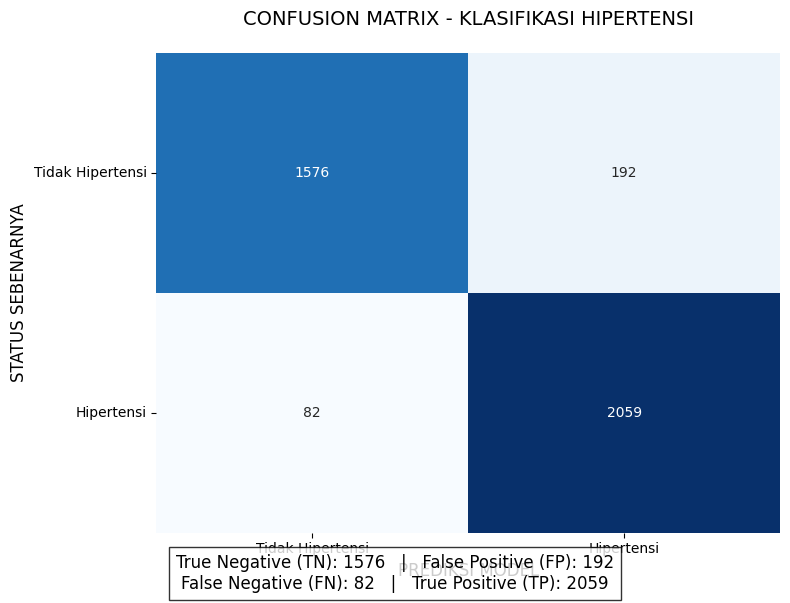


INTERPRETASI CONFUSION MATRIX:
--------------------------------
1. TRUE NEGATIVE (TN): 1576
   - Pasien TIDAK hipertensi dan diprediksi BENAR tidak hipertensi
   - Prediksi model: Negatif, Kenyataan: Negatif

2. FALSE POSITIVE (FP): 192
   - Pasien TIDAK hipertensi tapi diprediksi SALAH hipertensi
   - Prediksi model: Positif, Kenyataan: Negatif (Kesalahan Tipe I)

3. FALSE NEGATIVE (FN): 82
   - Pasien hipertensi tapi diprediksi SALAH tidak hipertensi
   - Prediksi model: Negatif, Kenyataan: Positif (Kesalahan Tipe II)

4. TRUE POSITIVE (TP): 2059
   - Pasien hipertensi dan diprediksi BENAR hipertensi
   - Prediksi model: Positif, Kenyataan: Positif


 Interpretasi Confusion Matrix:
- Sensitivitas (Recall): 96.1700% → Kemampuan mendeteksi hipertensi.
- Spesifisitas: 89.1403% → Kemampuan mengecualikan non-hipertensi.
- Model cenderung False Positive (lebih banyak prediksi hipertensi palsu).

 Laporan Final Model:
- Akurasi: 92.9905% → Klasifikasi benar secara global.
- F1-Score: 92.88

In [ ]:
# Prediksi harus berbasis a4_test dan best_thresh
# Gunakan threshold terbaik untuk prediksi dari a4_test (output layer terakhir)
y_pred = (a4_test >= best_thresh).astype(int)

# Pastikan y_test dan y_pred berbentuk 1D untuk evaluasi
y_test_flat = y_test.ravel()
y_pred_flat = y_pred.ravel()

# Evaluasi
print("Akurasi:", accuracy_score(y_test_flat, y_pred_flat))
print("Classification Report:\n", classification_report(y_test_flat, y_pred_flat))

# Ganti bagian confusion matrix dengan kode berikut:

# Hitung confusion matrix
conf_matrix = confusion_matrix(y_test_flat, y_pred_flat)

# Buat plot confusion matrix dengan label
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['Tidak Hipertensi', 'Hipertensi'],
            yticklabels=['Tidak Hipertensi', 'Hipertensi'])
plt.title('CONFUSION MATRIX - KLASIFIKASI HIPERTENSI', fontsize=14, pad=20)
plt.xlabel('PREDIKSI MODEL', fontsize=12)
plt.ylabel('STATUS SEBENARNYA', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# Tambahkan interpretasi nilai
plt.figtext(0.5, 0.01,
            f"True Negative (TN): {conf_matrix[0,0]}   |   False Positive (FP): {conf_matrix[0,1]}\n"
            f"False Negative (FN): {conf_matrix[1,0]}   |   True Positive (TP): {conf_matrix[1,1]}",
            ha="center",
            fontsize=12,
            bbox={"facecolor":"white", "alpha":0.8, "pad":5})
plt.show()

# Cetak penjelasan interpretasi
print("\nINTERPRETASI CONFUSION MATRIX:")
print("--------------------------------")
print("1. TRUE NEGATIVE (TN):", conf_matrix[0,0])
print("   - Pasien TIDAK hipertensi dan diprediksi BENAR tidak hipertensi")
print("   - Prediksi model: Negatif, Kenyataan: Negatif")
print()
print("2. FALSE POSITIVE (FP):", conf_matrix[0,1])
print("   - Pasien TIDAK hipertensi tapi diprediksi SALAH hipertensi")
print("   - Prediksi model: Positif, Kenyataan: Negatif (Kesalahan Tipe I)")
print()
print("3. FALSE NEGATIVE (FN):", conf_matrix[1,0])
print("   - Pasien hipertensi tapi diprediksi SALAH tidak hipertensi")
print("   - Prediksi model: Negatif, Kenyataan: Positif (Kesalahan Tipe II)")
print()
print("4. TRUE POSITIVE (TP):", conf_matrix[1,1])
print("   - Pasien hipertensi dan diprediksi BENAR hipertensi")
print("   - Prediksi model: Positif, Kenyataan: Positif")
print("\n" + "="*50)

# --------------------------
# 1. DEFINISIKAN FUNGSI TERLEBIH DAHULU
# --------------------------
def interpret_confusion_matrix(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print("\n Interpretasi Confusion Matrix:")
    print(f"- Sensitivitas (Recall): {sensitivity:.4%} → Kemampuan mendeteksi hipertensi.")
    print(f"- Spesifisitas: {specificity:.4%} → Kemampuan mengecualikan non-hipertensi.")

    if FP > FN:
        print("- Model cenderung False Positive (lebih banyak prediksi hipertensi palsu).")
    else:
        print("- Model cenderung False Negative (lebih banyak kasus hipertensi terlewat).")

def generate_report(test_accuracy, test_f1, conf_matrix):
    print("\n Laporan Final Model:")
    print(f"- Akurasi: {test_accuracy:.4%} → Klasifikasi benar secara global.")
    print(f"- F1-Score: {test_f1:.4%} → Keseimbangan precision-recall.")
    interpret_confusion_matrix(conf_matrix)

# Panggil fungsi interpretasi dan laporan
# Gunakan variabel test_accuracy, test_f1, dan conf_matrix yang dihitung di bagian atas sel ini
interpret_confusion_matrix(conf_matrix)
generate_report(test_accuracy, test_f1, conf_matrix)

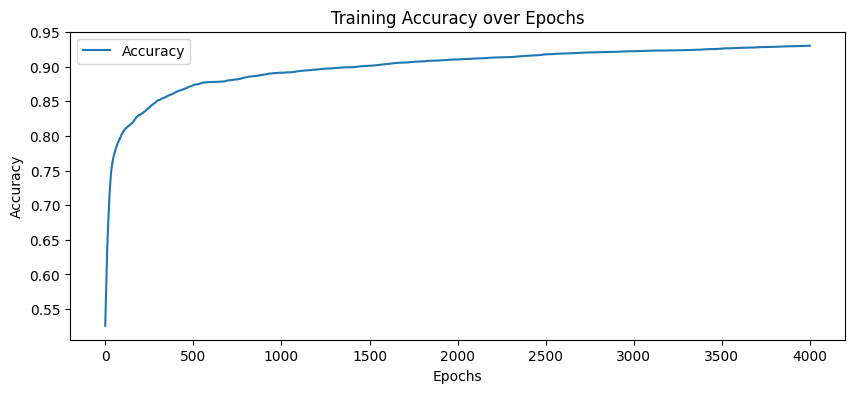

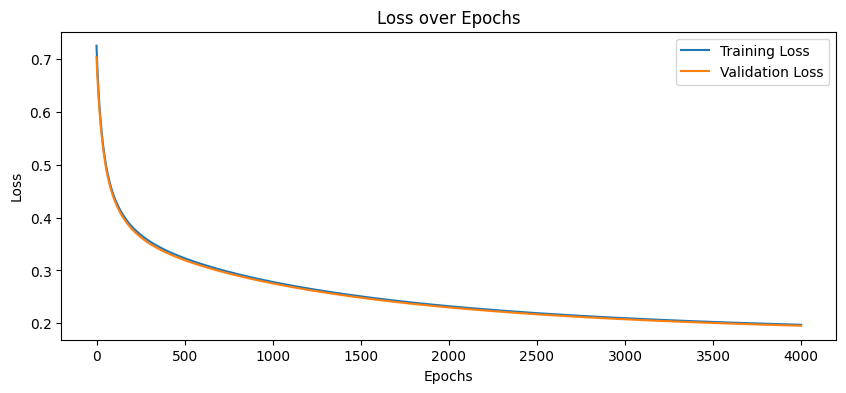

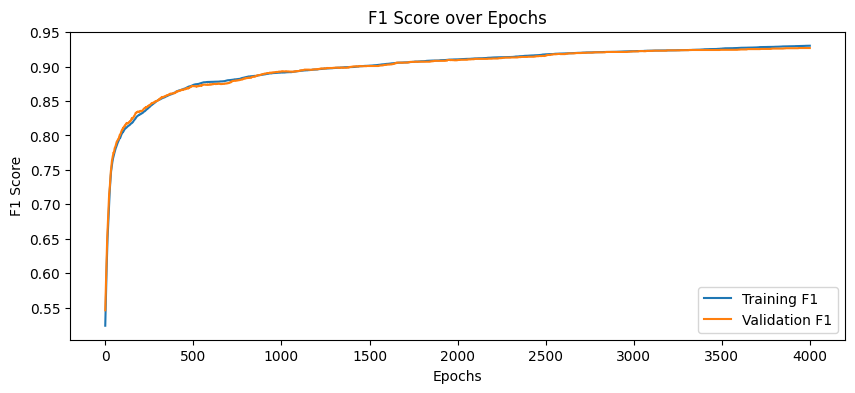

✅ Model konvergen dengan baik!


In [ ]:
# Plot akurasi
plt.figure(figsize=(10, 4))
plt.plot(range(len(accuracy_history)), accuracy_history, label='Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(range(len(loss_history)), loss_history, label='Training Loss')
plt.plot(range(len(val_loss_history)), val_loss_history, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot F1 score
plt.figure(figsize=(10, 4))
plt.plot(range(len(f1_history)), f1_history, label='Training F1')
plt.plot(range(len(val_f1_history)), val_f1_history, label='Validation F1')

plt.title('F1 Score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

def analyze_training_plots(loss_history, val_loss_history):
    if val_loss_history[-1] > loss_history[-1] * 1.2:
        print("⚠️ Overfitting terdeteksi: Validation loss > Training loss!")
        print("Solusi: Kurangi hidden layer, tambah regularisasi, atau augmentasi data.")
    elif val_loss_history[-1] < loss_history[-1]:
        print("✅ Model konvergen dengan baik!")
analyze_training_plots(loss_history, val_loss_history)

In [ ]:
# Akhir training neural network Anda
print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

# === MULAI KODE PREDIKSI BARU ===
# Contoh input baru (13 fitur)
new_input = [[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]]

# Standarisasi input
scaled_input = scaler.transform(new_input)

# Forward propagation untuk prediksi
z1 = np.dot(scaled_input, W1) + b1
a1 = relu(z1)
z2 = np.dot(a1, W2) + b2
a2 = sigmoid(z2)
prediction = (a2 > 0.5).astype(int)

print("Hasil prediksi (0 = tidak hipertensi, 1 = hipertensi):", prediction[0][0])


Epoch 4000/4000, Loss: 0.1972, Accuracy: 0.9303
Hasil prediksi (0 = tidak hipertensi, 1 = hipertensi): 1


Ground Truth:
[[1. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 0.]]
+---------+--------------+---------------+---------------+---------------+---------------+--------------+--------------+---------------+---------------+---------------+
| 2nd/1st |    TP0FP0    |     TP0FP1    |     TP0FP2    |     TP0FP3    |     TP0FP4    |    TP1FP0    |    TP1FP1    |     TP1FP2    |     TP1FP3    |     TP1FP4    |
+---------+--------------+---------------+---------------+---------------+---------------+--------------+--------------+---------------+---------------+---------------+
|  TP0FP0 | Loss: 8.0590 |  Loss: 9.6533 | Loss: 11.2475 | Loss: 12.8418 | Loss: 14.4360 | Loss: 6.4472 | Loss: 8.0415 |  Loss: 9.6357 | Loss: 11.2300 | Loss: 12.8242 |
|         |  F1: 0.2857  |   F1: 0.2857  |   F1: 0.2857  |   F1: 0.2857  |   F1: 0.2857  |  F1: 0.2857  |  F1: 0.2857  |   F1: 0.2857  |   F1: 0.2857  |   F1: 0.2857  |
|  TP0FP1 | Loss: 9.6533 | Loss: 11.2475 | Loss: 12.8418 | Loss: 14.4360 | Loss: 16.0302 | Loss

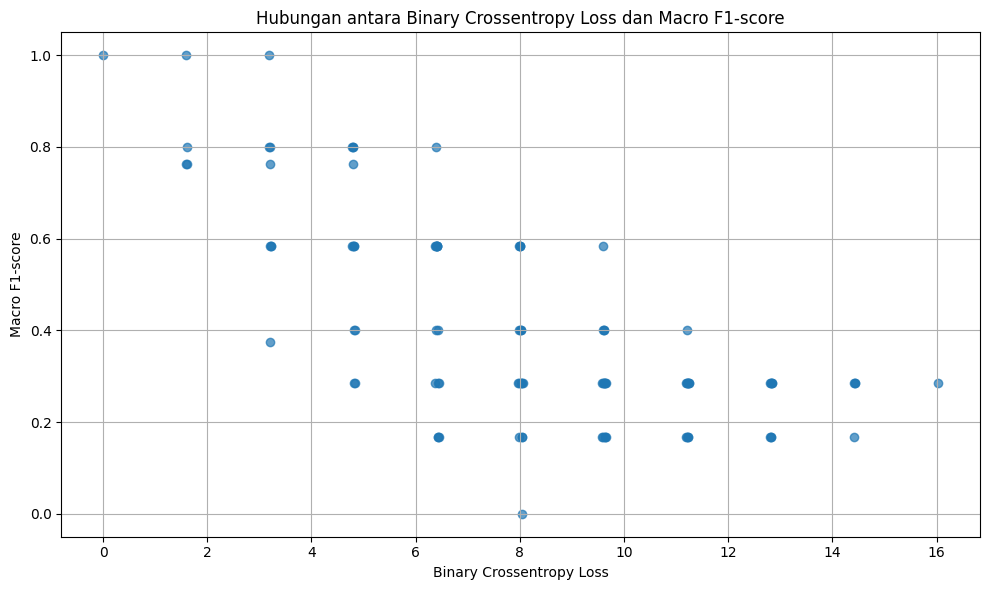

In [ ]:
# ground truth
Y = np.zeros((5, 2))
# first label is assigned to 20% of observations
Y[0:1, 0] = 1
# second label is assigned to 80% of observations
Y[0:4, 1] = 1

print("Ground Truth:")
print(Y)

# Membuat prediksi untuk kelas pertama
first = {}
for TP in range(2):  # True Positive untuk kelas pertama (0-1)
    for FP in range(5):  # False Positive untuk kelas pertama (0-4)
        name = f'TP{TP}FP{FP}'
        Yhat1 = np.zeros(5)
        # True Positive: prediksi positif di mana sebenarnya positif
        Yhat1[:TP] = 1
        # False Positive: prediksi positif di mana sebenarnya negatif
        Yhat1[5-FP:] = 1
        first[name] = Yhat1

# Membuat prediksi untuk kelas kedua
second = {}
for TP in range(5):  # True Positive untuk kelas kedua (0-4)
    for FP in range(2):  # False Positive untuk kelas kedua (0-1)
        name = f'TP{TP}FP{FP}'
        Yhat2 = np.zeros(5)
        # True Positive: prediksi positif di mana sebenarnya positif
        Yhat2[:TP] = 1
        # False Positive: prediksi positif di mana sebenarnya negatif
        Yhat2[5-FP:] = 1
        second[name] = Yhat2

# Membuat tabel perbandingan
t = PrettyTable()
t.field_names = ['2nd/1st'] + list(first.keys())

pltX = []
pltY = []

for name2, data2 in second.items():
    row = [name2]
    for name1, data1 in first.items():
        # Gabungkan prediksi untuk kedua kelas
        data = np.stack((data1, data2), axis=1)

        # Hitung binary crossentropy loss
        loss = np.mean(K.eval(binary_crossentropy(K.variable(Y), K.variable(data))))

        # Hitung F1-score (macro average)
        # Konversi ke format yang diharapkan oleh f1_score
        true_labels = np.argmax(Y, axis=1)
        pred_labels = np.argmax(data, axis=1)
        f1 = f1_score(true_labels, pred_labels, average='macro')

        pltX.append(loss)
        pltY.append(f1)
        row.append(f'Loss: {loss:.4f}\nF1: {f1:.4f}')

    t.add_row(row)

print(t)

# Plot hubungan antara loss dan F1-score
plt.figure(figsize=(10, 6))
plt.scatter(pltX, pltY, alpha=0.7)
plt.title('Hubungan antara Binary Crossentropy Loss dan Macro F1-score')
plt.ylabel('Macro F1-score')
plt.xlabel('Binary Crossentropy Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

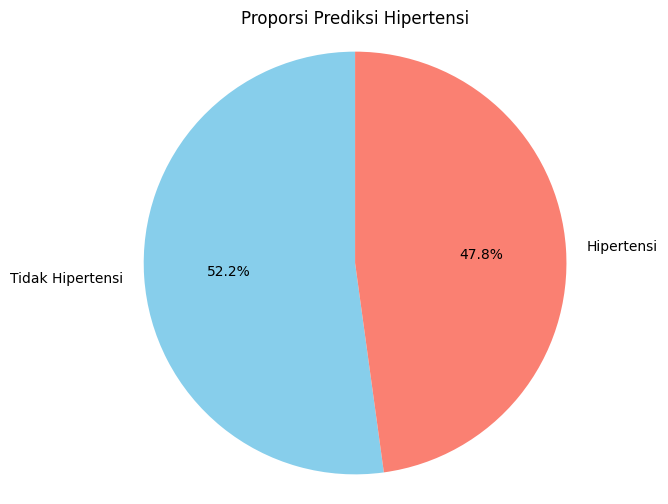


Probabilitas Prediksi (Beberapa Baris Pertama):
Data ke-1: Probabilitas Hipertensi = 0.7097
Data ke-2: Probabilitas Hipertensi = 0.5846
Data ke-3: Probabilitas Hipertensi = 0.1410
Data ke-4: Probabilitas Hipertensi = 0.9544
Data ke-5: Probabilitas Hipertensi = 0.3170
Data ke-6: Probabilitas Hipertensi = 0.0231
Data ke-7: Probabilitas Hipertensi = 0.1244
Data ke-8: Probabilitas Hipertensi = 0.9437
Data ke-9: Probabilitas Hipertensi = 0.5449
Data ke-10: Probabilitas Hipertensi = 0.6295

📊 Laporan Final Model:
- Akurasi: 92.99% → Klasifikasi benar secara global.
- F1-Score: 92.88% → Keseimbangan precision-recall.

 Interpretasi Confusion Matrix:
- Sensitivitas (Recall): 96.1700% → Kemampuan mendeteksi hipertensi.
- Spesifisitas: 89.1403% → Kemampuan mengecualikan non-hipertensi.
- Model cenderung False Positive (lebih banyak prediksi hipertensi palsu).


In [ ]:
# forward propagation logic used earlier.
def predict_jst(X, W1, b1, W2, b2):
    """Performs forward propagation for prediction."""
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1) # Use the relu activation function
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2) # Use the sigmoid activation function
    predictions = (a2 > 0.5).astype(int)
    return predictions, a2 # Return predictions and probabilities

def main():
    # 1. Load data
    df_predict = pd.read_csv('/content/drive/MyDrive/projek pkc/archive/hypertension_data.csv')

    # Preprocess the data the same way as the training data
    df_predict.replace('?', np.nan, inplace=True)
    df_predict = df_predict.apply(pd.to_numeric, errors='coerce')
    df_predict.dropna(inplace=True)

    # Select features, excluding the target
    X_predict = df_predict.drop('target', axis=1).values

    # 2. Standarisasi data baru menggunakan scaler yang sudah dilatih data X_predict memiliki jumlah fitur yang sama dengan X_train (13 fitur)
    X_predict_scaled = scaler.transform(X_predict)

    # 3. Bobot dan bias JST menggunakan hasil training global
    # (W1, b1, W2, b2 dari training loop sebelumnya)
    # Tidak perlu mendefinisikan ulang bobot dan bias di sini.
    # Mereka sudah ada di lingkungan global setelah training.

    # 4. Prediksi menggunakan bobot dan bias hasil training
    predictions, probs = predict_jst(X_predict_scaled, W1, b1, W2, b2)

    # 5. Hitung jumlah tiap kelas dan tampilkan pie chart
    unique, counts = np.unique(predictions, return_counts=True)
    # Ensure all possible prediction classes (0 and 1) are considered, even if not present
    count_dict = dict(zip(unique.flatten(), counts))
    labels = ['Tidak Hipertensi', 'Hipertensi']
    sizes = [count_dict.get(0, 0), count_dict.get(1, 0)]

    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
    plt.title('Proporsi Prediksi Hipertensi')
    plt.axis('equal')
    plt.show()

    # 6. (Opsional) Cetak probabilitas tiap baris (Contoh hanya beberapa baris)
    # Hanya cetak untuk beberapa baris pertama atau acak karena dataset besar
    print("\nProbabilitas Prediksi (Beberapa Baris Pertama):")
    for i, prob in enumerate(probs.flatten()[:10], start=1): # Cetak hanya 10 baris pertama
        print(f"Data ke-{i}: Probabilitas Hipertensi = {prob:.4f}")

# Panggil fungsi main() supaya langsung dieksekusi
main()

def generate_report(test_accuracy, test_f1, conf_matrix):
    print("\n📊 Laporan Final Model:")
    print(f"- Akurasi: {test_accuracy:.2%} → Klasifikasi benar secara global.")
    print(f"- F1-Score: {test_f1:.2%} → Keseimbangan precision-recall.")
    interpret_confusion_matrix(conf_matrix)
generate_report(test_accuracy, test_f1, conf_matrix)